# 2D Finite Element Method from Scratch

**Building a Complete FEM Solver for Linear Elasticity**

In this notebook, we'll implement a simple 2D FEM solver and solve the Navier-Cauchy equation step by step.

---

## Table of Contents
1. [Problem Statement](#section1)
2. [Theory: From Navier-Cauchy to FEM](#section2)
3. [Step 1: Create the Mesh](#section3)
4. [Step 2: Shape Functions](#section4)
5. [Step 3: Strain-Displacement Matrix B](#section5)
6. [Step 4: Elasticity Matrix D](#section6)
7. [Step 5: Element Stiffness Matrix](#section7)
8. [Step 6: Global Assembly](#section8)
9. [Step 7: Boundary Conditions](#section9)
10. [Step 8: Solve the System](#section10)
11. [Step 9: Post-Processing](#section11)
12. [Complete Example: Cantilever Beam](#section12)
13. [Comparison with Analytical Solution](#section13)

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri
from matplotlib.patches import FancyArrowPatch, Polygon
from matplotlib.collections import PolyCollection
import scipy.sparse as sp
from scipy.sparse.linalg import spsolve
import warnings
warnings.filterwarnings('ignore')

# Plotting configuration
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['font.size'] = 11
plt.rcParams['lines.linewidth'] = 2

print("✓ Libraries loaded successfully")

✓ Libraries loaded successfully


---
<a id='section1'></a>
## 1. Problem Statement

We'll solve a classic problem: **2D rectangular cantilever beam under point load**

### Geometry:
- Length: L = 10 m
- Height: H = 2 m
- Thickness: t = 0.1 m (plane stress)

### Material (Steel):
- Young's modulus: E = 200 GPa
- Poisson's ratio: ν = 0.3

### Boundary Conditions:
- **Fixed** at left edge (x = 0): u = 0, v = 0
- **Point load** at bottom-right corner: F = -1000 N (downward)

### Goal:
Find displacement field (u, v) that satisfies the **Navier-Cauchy equation**:
$$\boxed{(\lambda + \mu) \nabla(\nabla \cdot \mathbf{u}) + \mu \nabla^2 \mathbf{u} = \mathbf{0}}$$

In [21]:
# Problem parameters
L = 10.0  # Length [m]
H = 2.0   # Height [m]
t = 0.1   # Thickness [m]
E = 200e9 # Young's modulus [Pa]
nu = 0.3  # Poisson's ratio
F = -1000 # Applied force [N] (negative = downward)

print("📋 Problem Parameters:")
print("=" * 50)
print(f"Geometry: {L} m × {H} m × {t} m")
print(f"Material: E = {E/1e9:.0f} GPa, ν = {nu}")
print(f"Loading: F = {F} N (point load at bottom-right)")
print(f"BC: Fixed at x = 0")

# Compute Lamé parameters
mu = E / (2 * (1 + nu))
lam = E * nu / ((1 + nu) * (1 - 2 * nu))
print(f"\nLamé parameters:")
print(f"  μ = {mu/1e9:.2f} GPa")
print(f"  λ = {lam/1e9:.2f} GPa")

📋 Problem Parameters:
Geometry: 10.0 m × 2.0 m × 0.1 m
Material: E = 200 GPa, ν = 0.3
Loading: F = -1000 N (point load at bottom-right)
BC: Fixed at x = 0

Lamé parameters:
  μ = 76.92 GPa
  λ = 115.38 GPa


---
<a id='section2'></a>
## 2. Theory: From Navier-Cauchy to FEM

### The Journey:

```
Navier-Cauchy PDE (Strong Form)
        ↓
Weak Form (Principle of Virtual Work)
        ↓
Discretization (Mesh + Shape Functions)
        ↓
Element Matrices (Kᵉ = ∫BᵀDB dΩ)
        ↓
Global Assembly (K·d = F)
        ↓
Apply Boundary Conditions
        ↓
Solve Linear System
        ↓
Post-process (ε = Bd, σ = Dε)
```

### Key Equations:

**Strain-Displacement:**
$$\boldsymbol{\varepsilon} = \begin{bmatrix} \varepsilon_{xx} \\ \varepsilon_{yy} \\ \gamma_{xy} \end{bmatrix} = \begin{bmatrix} \frac{\partial u}{\partial x} \\ \frac{\partial v}{\partial y} \\ \frac{\partial u}{\partial y} + \frac{\partial v}{\partial x} \end{bmatrix} = \mathbf{B} \mathbf{d}^e$$

**Stress-Strain (Hooke's Law):**
$$\boldsymbol{\sigma} = \begin{bmatrix} \sigma_{xx} \\ \sigma_{yy} \\ \tau_{xy} \end{bmatrix} = \mathbf{D} \boldsymbol{\varepsilon}$$

**Element Stiffness:**
$$\mathbf{K}^e = \int_{\Omega^e} \mathbf{B}^T \mathbf{D} \mathbf{B} \, d\Omega$$

For constant strain triangles (CST), this becomes:
$$\mathbf{K}^e = t \cdot A^e \cdot \mathbf{B}^T \mathbf{D} \mathbf{B}$$

---
<a id='section3'></a>
## 3. Step 1: Create the Mesh

We'll create a structured triangular mesh for our rectangular domain.

✓ Mesh created:
  Nodes: 105
  Elements: 160
  DOF: 210


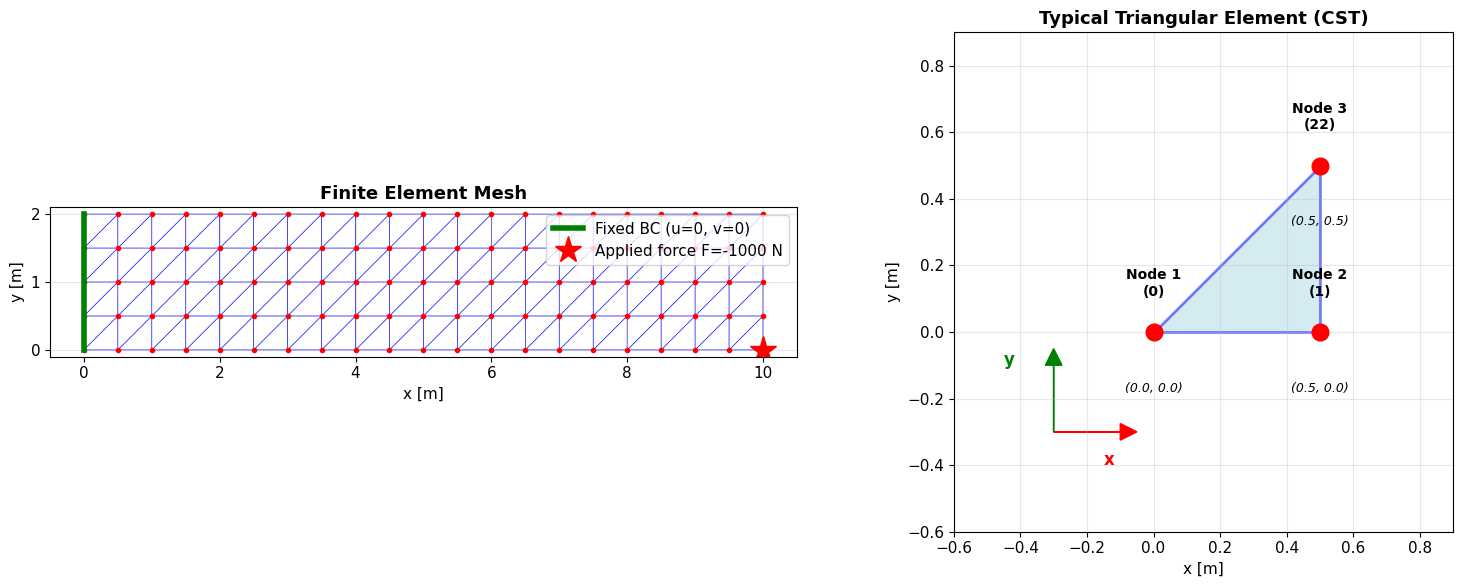


📌 Mesh Details:
  Element type: 3-node triangle (Constant Strain Triangle - CST)
  DOF per node: 2 (u, v)
  DOF per element: 6
  Total system size: 210 × 210


In [22]:
def create_rectangular_mesh(L, H, nx, ny):
    """
    Create a structured triangular mesh for a rectangle.
    
    Parameters:
    -----------
    L, H : float
        Length and height of rectangle
    nx, ny : int
        Number of divisions in x and y
    
    Returns:
    --------
    nodes : ndarray (n_nodes, 2)
        Node coordinates [x, y]
    elements : ndarray (n_elements, 3)
        Element connectivity [node1, node2, node3]
    """
    # Generate grid points
    x = np.linspace(0, L, nx + 1)
    y = np.linspace(0, H, ny + 1)
    X, Y = np.meshgrid(x, y)
    
    # Node coordinates
    nodes = np.column_stack([X.ravel(), Y.ravel()])
    n_nodes = len(nodes)
    
    # Element connectivity (2 triangles per quad)
    elements = []
    for j in range(ny):
        for i in range(nx):
            # Node indices of quad
            n0 = j * (nx + 1) + i
            n1 = n0 + 1
            n2 = n0 + (nx + 1) + 1
            n3 = n0 + (nx + 1)
            
            # Two triangles
            elements.append([n0, n1, n2])  # Lower-right triangle
            elements.append([n0, n2, n3])  # Upper-left triangle
    
    elements = np.array(elements)
    
    return nodes, elements

# Create mesh
nx, ny = 20, 4  # Number of divisions
nodes, elements = create_rectangular_mesh(L, H, nx, ny)

n_nodes = len(nodes)
n_elements = len(elements)
n_dof = 2 * n_nodes  # 2 DOF per node (u, v)

print(f"✓ Mesh created:")
print(f"  Nodes: {n_nodes}")
print(f"  Elements: {n_elements}")
print(f"  DOF: {n_dof}")

# Visualize mesh
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Full mesh
ax = axes[0]
triangulation = tri.Triangulation(nodes[:, 0], nodes[:, 1], elements)
ax.triplot(triangulation, 'b-', linewidth=0.5)
ax.plot(nodes[:, 0], nodes[:, 1], 'ro', markersize=3)
ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')
ax.set_title('Finite Element Mesh', fontsize=13, weight='bold')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

# Annotate boundary conditions
ax.plot([0, 0], [0, H], 'g-', linewidth=4, label='Fixed BC (u=0, v=0)')
ax.plot(L, 0, 'r*', markersize=20, label=f'Applied force F={F} N')
ax.legend(loc='upper right')

# Zoomed view of one element
ax = axes[1]
elem_idx = 0  # First element
elem_nodes = elements[elem_idx]
elem_coords = nodes[elem_nodes]

# Draw element
triangle = Polygon(elem_coords, fill=True, facecolor='lightblue', 
                   edgecolor='blue', linewidth=2, alpha=0.5)
ax.add_patch(triangle)

# Label nodes
for i, (node_idx, coord) in enumerate(zip(elem_nodes, elem_coords)):
    ax.plot(coord[0], coord[1], 'ro', markersize=12)
    ax.text(coord[0], coord[1] + 0.1, f'Node {i+1}\n({node_idx})', 
            ha='center', va='bottom', fontsize=10, weight='bold')
    ax.text(coord[0], coord[1] - 0.15, f'({coord[0]:.1f}, {coord[1]:.1f})', 
            ha='center', va='top', fontsize=9, style='italic')

# Add local coordinate system
ax.arrow(elem_coords[0, 0] - 0.3, elem_coords[0, 1] - 0.3, 0.2, 0, 
         head_width=0.05, head_length=0.05, fc='red', ec='red')
ax.arrow(elem_coords[0, 0] - 0.3, elem_coords[0, 1] - 0.3, 0, 0.2, 
         head_width=0.05, head_length=0.05, fc='green', ec='green')
ax.text(elem_coords[0, 0] - 0.15, elem_coords[0, 1] - 0.4, 'x', color='red', fontsize=12, weight='bold')
ax.text(elem_coords[0, 0] - 0.45, elem_coords[0, 1] - 0.1, 'y', color='green', fontsize=12, weight='bold')

ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')
ax.set_title('Typical Triangular Element (CST)', fontsize=13, weight='bold')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.set_xlim(elem_coords[:, 0].min() - 0.6, elem_coords[:, 0].max() + 0.4)
ax.set_ylim(elem_coords[:, 1].min() - 0.6, elem_coords[:, 1].max() + 0.4)

plt.tight_layout()
plt.show()

print("\n📌 Mesh Details:")
print(f"  Element type: 3-node triangle (Constant Strain Triangle - CST)")
print(f"  DOF per node: 2 (u, v)")
print(f"  DOF per element: 6")
print(f"  Total system size: {n_dof} × {n_dof}")

---
<a id='section4'></a>
## 4. Step 2: Shape Functions

For a **3-node triangle (CST)**, we use **linear shape functions**:

$$N_i(x, y) = \frac{1}{2A}(a_i + b_i x + c_i y)$$

Where:
- $A$ = element area
- Coefficients depend on node coordinates

The displacement field is interpolated as:
$$u(x,y) = N_1 u_1 + N_2 u_2 + N_3 u_3$$
$$v(x,y) = N_1 v_1 + N_2 v_2 + N_3 v_3$$

**Key property:** Strains are **constant** within each element (CST = Constant Strain Triangle)

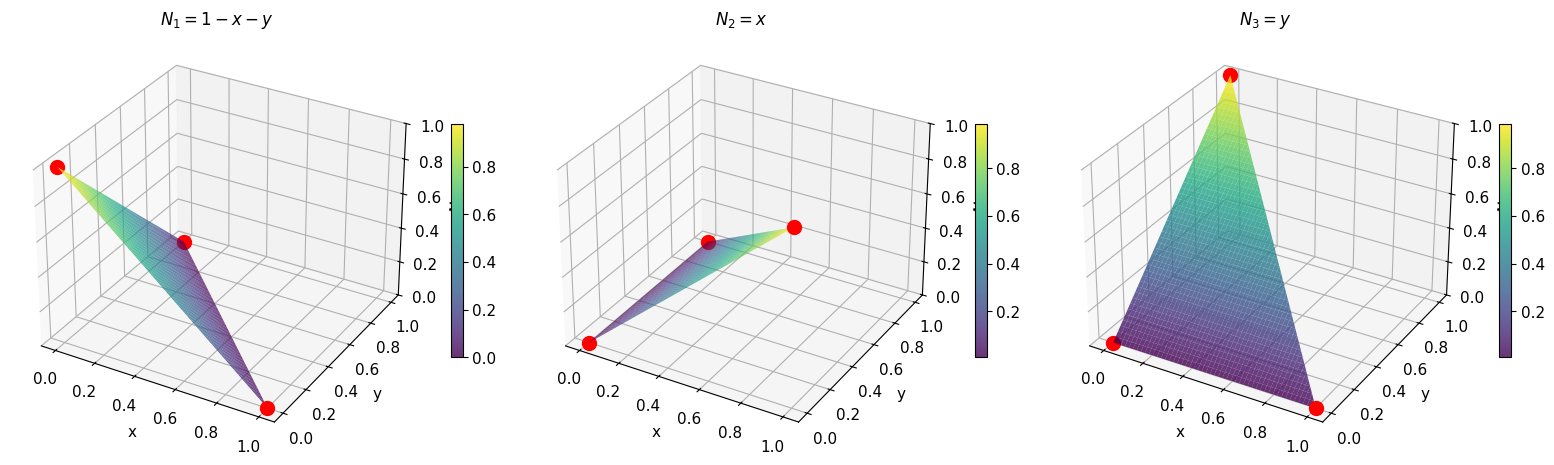


📐 Shape Function Properties:
  • N_i = 1 at node i, N_i = 0 at other nodes
  • Σ N_i = 1 (partition of unity)
  • Linear in x and y
  • ∂N_i/∂x and ∂N_i/∂y are CONSTANTS → constant strain


In [23]:
def compute_element_area(coords):
    """
    Compute area of triangle using cross product.
    
    coords : ndarray (3, 2)
        Coordinates of 3 nodes [[x1,y1], [x2,y2], [x3,y3]]
    """
    x1, y1 = coords[0]
    x2, y2 = coords[1]
    x3, y3 = coords[2]
    
    area = 0.5 * abs((x2 - x1) * (y3 - y1) - (x3 - x1) * (y2 - y1))
    return area

# Visualize shape functions
fig = plt.figure(figsize=(16, 5))

# Reference triangle for visualization
ref_coords = np.array([[0, 0], [1, 0], [0, 1]])

# Create fine grid for plotting
n_plot = 50
x_plot = np.linspace(0, 1, n_plot)
y_plot = np.linspace(0, 1, n_plot)
X_plot, Y_plot = np.meshgrid(x_plot, y_plot)

# Mask for triangle
mask = X_plot + Y_plot <= 1

# Shape functions
N1 = 1 - X_plot - Y_plot
N2 = X_plot
N3 = Y_plot

N1[~mask] = np.nan
N2[~mask] = np.nan
N3[~mask] = np.nan

for i, (N, title) in enumerate([(N1, '$N_1 = 1 - x - y$'), 
                                   (N2, '$N_2 = x$'), 
                                   (N3, '$N_3 = y$')]):
    ax = fig.add_subplot(1, 3, i+1, projection='3d')
    surf = ax.plot_surface(X_plot, Y_plot, N, cmap='viridis', alpha=0.8)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel(f'$N_{i+1}$')
    ax.set_title(title, fontsize=12, weight='bold')
    ax.set_zlim(0, 1)
    plt.colorbar(surf, ax=ax, shrink=0.5)
    
    # Mark nodes
    for j, coord in enumerate(ref_coords):
        row_idx = int(coord[1] * (n_plot - 1))
        col_idx = int(coord[0] * (n_plot - 1))
        
        val = N[row_idx, col_idx] if not np.isnan(N[row_idx, col_idx]) else 0
        ax.scatter([coord[0]], [coord[1]], [val], color='red', s=100, zorder=10)

plt.tight_layout()
plt.show()

print("\n📐 Shape Function Properties:")
print("  • N_i = 1 at node i, N_i = 0 at other nodes")
print("  • Σ N_i = 1 (partition of unity)")
print("  • Linear in x and y")
print("  • ∂N_i/∂x and ∂N_i/∂y are CONSTANTS → constant strain")

---
<a id='section5'></a>
## 5. Step 3: Strain-Displacement Matrix B

The **B matrix** relates nodal displacements to strains:

$$\boldsymbol{\varepsilon} = \mathbf{B} \mathbf{d}^e$$

For a 3-node triangle:

$$\mathbf{B} = \frac{1}{2A} \begin{bmatrix}
b_1 & 0 & b_2 & 0 & b_3 & 0 \\
0 & c_1 & 0 & c_2 & 0 & c_3 \\
c_1 & b_1 & c_2 & b_2 & c_3 & b_3
\end{bmatrix}$$

Where:
- $b_i = y_j - y_k$ (cyclic: i=1→j=2,k=3; i=2→j=3,k=1; i=3→j=1,k=2)
- $c_i = x_k - x_j$ (cyclic)
- $A$ = element area

This comes from:
$$\varepsilon_{xx} = \frac{\partial u}{\partial x} = \sum_i \frac{\partial N_i}{\partial x} u_i$$


🔢 Example: B Matrix for First Element
Element nodes: [ 0  1 22]
Node coordinates:
  Node 1: (0.000, 0.000)
  Node 2: (0.500, 0.000)
  Node 3: (0.500, 0.500)

Element area: 0.125000 m²

B matrix (3×6):
   [u1  v1  u2  v2  u3  v3]
ε_xx  [-2.0000  0.0000  2.0000  0.0000  0.0000  0.0000]
ε_yy  [ 0.0000  0.0000  0.0000 -2.0000  0.0000  2.0000]
γ_xy  [ 0.0000 -2.0000 -2.0000  2.0000  2.0000  0.0000]


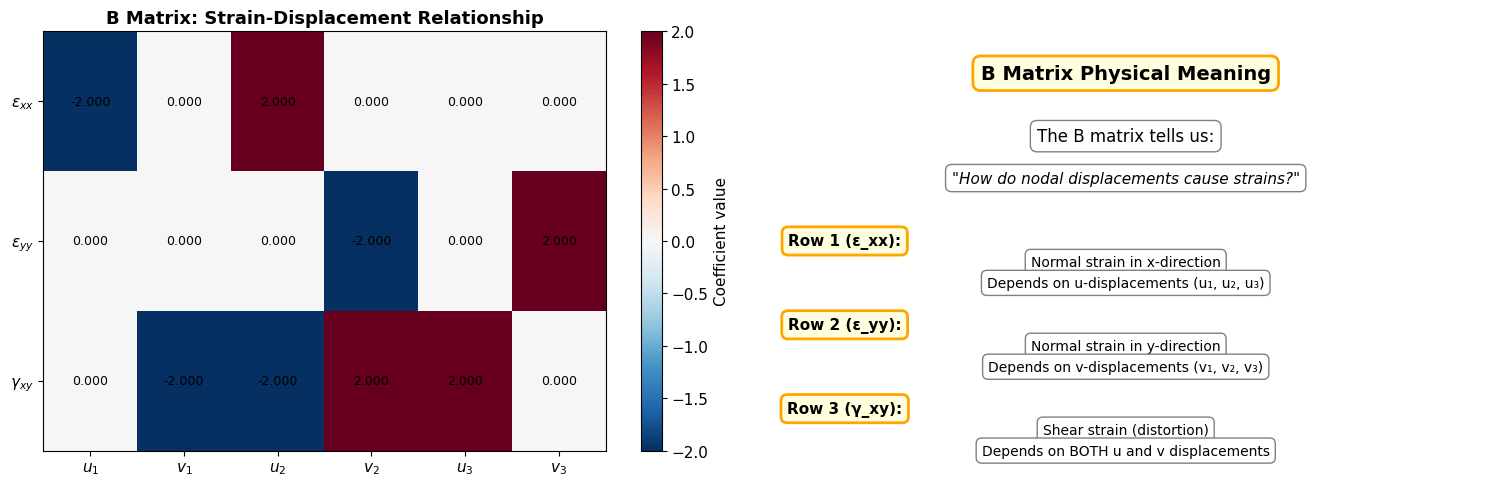


✅ Key Point: B matrix is CONSTANT for each element (CST property)
   → Strains are uniform within each triangle
   → Simple to compute, but less accurate than higher-order elements


In [24]:
def compute_B_matrix(coords):
    """
    Compute strain-displacement matrix B for a 3-node triangle.
    
    Parameters:
    -----------
    coords : ndarray (3, 2)
        Node coordinates [[x1,y1], [x2,y2], [x3,y3]]
    
    Returns:
    --------
    B : ndarray (3, 6)
        Strain-displacement matrix
    A : float
        Element area
    """
    x1, y1 = coords[0]
    x2, y2 = coords[1]
    x3, y3 = coords[2]
    
    # Compute area
    A = 0.5 * abs((x2 - x1) * (y3 - y1) - (x3 - x1) * (y2 - y1))
    
    # Compute b and c coefficients (cyclic)
    b1 = y2 - y3
    b2 = y3 - y1
    b3 = y1 - y2
    
    c1 = x3 - x2
    c2 = x1 - x3
    c3 = x2 - x1
    
    # Assemble B matrix
    B = (1 / (2 * A)) * np.array([
        [b1,  0, b2,  0, b3,  0],  # ε_xx = ∂u/∂x
        [ 0, c1,  0, c2,  0, c3],  # ε_yy = ∂v/∂y
        [c1, b1, c2, b2, c3, b3]   # γ_xy = ∂u/∂y + ∂v/∂x
    ])
    
    return B, A

# Example: compute B for first element
elem_idx = 0
elem_coords = nodes[elements[elem_idx]]
B_example, A_example = compute_B_matrix(elem_coords)

print("\n🔢 Example: B Matrix for First Element")
print("=" * 60)
print(f"Element nodes: {elements[elem_idx]}")
print(f"Node coordinates:")
for i, coord in enumerate(elem_coords):
    print(f"  Node {i+1}: ({coord[0]:.3f}, {coord[1]:.3f})")
print(f"\nElement area: {A_example:.6f} m²")
print(f"\nB matrix (3×6):")
print("   [u1  v1  u2  v2  u3  v3]")
labels = ['ε_xx', 'ε_yy', 'γ_xy']
for i, row in enumerate(B_example):
    print(f"{labels[i]:5s} [{' '.join([f'{val:7.4f}' for val in row])}]")

# Visualize B matrix
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Heatmap of B matrix
ax = axes[0]
im = ax.imshow(B_example, cmap='RdBu_r', aspect='auto')
ax.set_xticks(range(6))
ax.set_xticklabels(['$u_1$', '$v_1$', '$u_2$', '$v_2$', '$u_3$', '$v_3$'])
ax.set_yticks(range(3))
ax.set_yticklabels(['$\\varepsilon_{xx}$', '$\\varepsilon_{yy}$', '$\\gamma_{xy}$'])
ax.set_title('B Matrix: Strain-Displacement Relationship', fontsize=13, weight='bold')
plt.colorbar(im, ax=ax, label='Coefficient value')

# Add values to cells
for i in range(3):
    for j in range(6):
        text = ax.text(j, i, f'{B_example[i, j]:.3f}',
                      ha="center", va="center", color="black", fontsize=9)

# Physical interpretation
ax = axes[1]
ax.axis('off')
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)

text_content = [
    (5, 9, "B Matrix Physical Meaning", 14, 'bold'),
    (5, 7.5, "The B matrix tells us:", 12, 'normal'),
    (5, 6.5, "\"How do nodal displacements cause strains?\"", 11, 'italic'),
    (1, 5, "Row 1 (ε_xx):", 11, 'bold'),
    (5, 4.5, "Normal strain in x-direction", 10, 'normal'),
    (5, 4, "Depends on u-displacements (u₁, u₂, u₃)", 10, 'normal'),
    (1, 3, "Row 2 (ε_yy):", 11, 'bold'),
    (5, 2.5, "Normal strain in y-direction", 10, 'normal'),
    (5, 2, "Depends on v-displacements (v₁, v₂, v₃)", 10, 'normal'),
    (1, 1, "Row 3 (γ_xy):", 11, 'bold'),
    (5, 0.5, "Shear strain (distortion)", 10, 'normal'),
    (5, 0, "Depends on BOTH u and v displacements", 10, 'normal'),
]

for x, y, text, size, weight in text_content:
    text_style = 'italic' if weight == 'italic' else 'normal'
    actual_weight = 'normal' if weight == 'italic' else weight
    
    ax.text(x, y, text, ha='center', va='center', fontsize=size, 
            weight=actual_weight, style=text_style,
            bbox=dict(boxstyle='round,pad=0.4', 
                     facecolor='lightyellow' if weight == 'bold' else 'white', 
                     edgecolor='orange' if weight == 'bold' else 'gray', 
                     linewidth=2 if weight == 'bold' else 1))

plt.tight_layout()
plt.show()

print("\n✅ Key Point: B matrix is CONSTANT for each element (CST property)")
print("   → Strains are uniform within each triangle")
print("   → Simple to compute, but less accurate than higher-order elements")

---
<a id='section6'></a>
## 6. Step 4: Elasticity Matrix D

The **D matrix** relates stress to strain (Hooke's law):

$$\boldsymbol{\sigma} = \mathbf{D} \boldsymbol{\varepsilon}$$

### Plane Stress (thin plates, σ_zz = 0):
$$\mathbf{D} = \frac{E}{1-\nu^2} \begin{bmatrix}
1 & \nu & 0 \\
\nu & 1 & 0 \\
0 & 0 & \frac{1-\nu}{2}
\end{bmatrix}$$

### Plane Strain (thick sections, ε_zz = 0):
$$\mathbf{D} = \frac{E}{(1+\nu)(1-2\nu)} \begin{bmatrix}
1-\nu & \nu & 0 \\
\nu & 1-\nu & 0 \\
0 & 0 & \frac{1-2\nu}{2}
\end{bmatrix}$$

We'll use **plane stress** (appropriate for thin beams).


🔢 Elasticity Matrix D (Plane Stress)
Material: E = 200 GPa, ν = 0.3

D matrix (3×3):
         [ε_xx    ε_yy    γ_xy]
σ_xx  [ 219.780   65.934    0.000] GPa
σ_yy  [  65.934  219.780    0.000] GPa
τ_xy  [   0.000    0.000   76.923] GPa


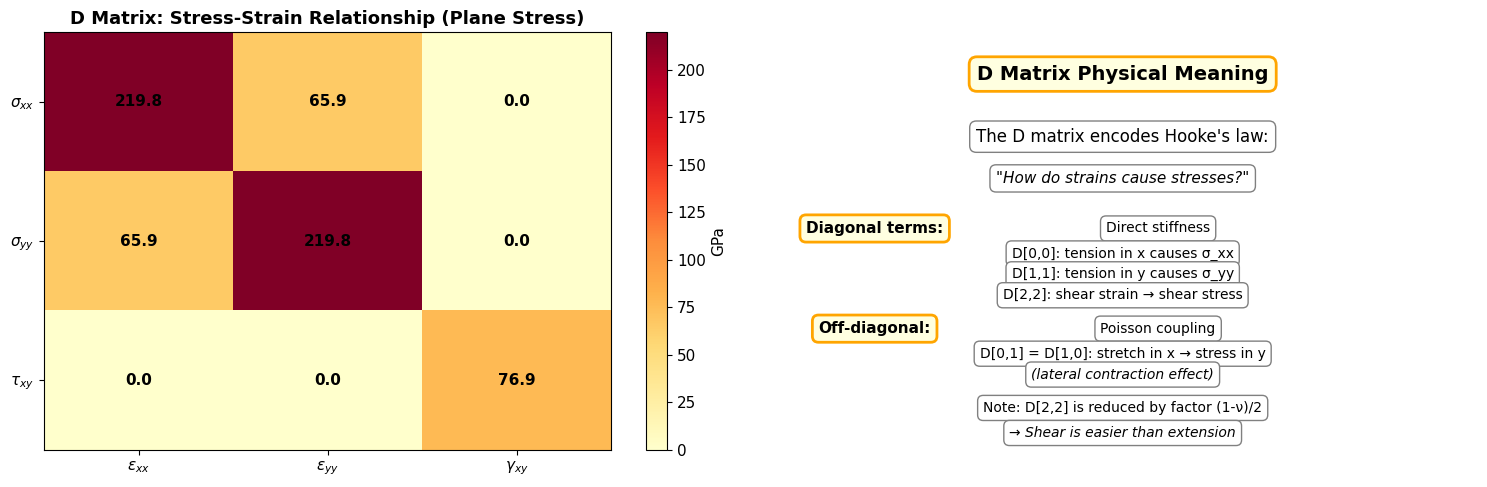


📊 Plane Stress vs Plane Strain:
Plane Stress D[0,0]: 219.780 GPa
Plane Strain D[0,0]: 269.231 GPa

Plane stress is ~1.22× stiffer in extension

📌 When to use which?
  Plane Stress:  thin structures (plates, shells)
  Plane Strain:  thick structures (dams, tunnels)

  Our beam: thickness = 0.1 m, length = 10.0 m
  Ratio t/L = 0.010 << 1 → Use PLANE STRESS ✓


In [25]:
def compute_D_matrix(E, nu, plane_stress=True):
    """
    Compute elasticity matrix D.
    
    Parameters:
    -----------
    E : float
        Young's modulus [Pa]
    nu : float
        Poisson's ratio
    plane_stress : bool
        True for plane stress, False for plane strain
    
    Returns:
    --------
    D : ndarray (3, 3)
        Elasticity matrix
    """
    if plane_stress:
        factor = E / (1 - nu**2)
        D = factor * np.array([
            [1,  nu,          0],
            [nu, 1,           0],
            [0,  0, (1-nu)/2]
        ])
    else:  # plane strain
        factor = E / ((1 + nu) * (1 - 2*nu))
        D = factor * np.array([
            [1-nu, nu,            0],
            [nu,   1-nu,          0],
            [0,    0, (1-2*nu)/2]
        ])
    
    return D

# Compute D matrix for our problem
D = compute_D_matrix(E, nu, plane_stress=True)

print("\n🔢 Elasticity Matrix D (Plane Stress)")
print("=" * 60)
print(f"Material: E = {E/1e9:.0f} GPa, ν = {nu}")
print(f"\nD matrix (3×3):")
print("         [ε_xx    ε_yy    γ_xy]")
labels = ['σ_xx', 'σ_yy', 'τ_xy']
for i, row in enumerate(D):
    print(f"{labels[i]:5s} [{' '.join([f'{val/1e9:8.3f}' for val in row])}] GPa")

# Visualize D matrix
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Heatmap of D matrix
ax = axes[0]
im = ax.imshow(D/1e9, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(3))
ax.set_xticklabels(['$\\varepsilon_{xx}$', '$\\varepsilon_{yy}$', '$\\gamma_{xy}$'])
ax.set_yticks(range(3))
ax.set_yticklabels(['$\\sigma_{xx}$', '$\\sigma_{yy}$', '$\\tau_{xy}$'])
ax.set_title('D Matrix: Stress-Strain Relationship (Plane Stress)', fontsize=13, weight='bold')
plt.colorbar(im, ax=ax, label='GPa')

# Add values to cells
for i in range(3):
    for j in range(3):
        text = ax.text(j, i, f'{D[i, j]/1e9:.1f}',
                      ha="center", va="center", color="black", fontsize=11, weight='bold')

# Physical interpretation
ax = axes[1]
ax.axis('off')
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)

text_content = [
    (5, 9, "D Matrix Physical Meaning", 14, 'bold'),
    (5, 7.5, "The D matrix encodes Hooke's law:", 12, 'normal'),
    (5, 6.5, "\"How do strains cause stresses?\"", 11, 'italic'),
    (1.5, 5.3, "Diagonal terms:", 11, 'bold'),
    (5.5, 5.3, "Direct stiffness", 10, 'normal'),
    (5, 4.7, "D[0,0]: tension in x causes σ_xx", 10, 'normal'),
    (5, 4.2, "D[1,1]: tension in y causes σ_yy", 10, 'normal'),
    (5, 3.7, "D[2,2]: shear strain → shear stress", 10, 'normal'),
    (1.5, 2.9, "Off-diagonal:", 11, 'bold'),
    (5.5, 2.9, "Poisson coupling", 10, 'normal'),
    (5, 2.3, "D[0,1] = D[1,0]: stretch in x → stress in y", 10, 'normal'),
    (5, 1.8, "(lateral contraction effect)", 10, 'italic'),
    (5, 1, "Note: D[2,2] is reduced by factor (1-ν)/2", 10, 'normal'),
    (5, 0.4, "→ Shear is easier than extension", 10, 'italic'),
]

for x, y, text, size, weight in text_content:
    # Handle italic: use style parameter instead of weight
    text_style = 'italic' if weight == 'italic' else 'normal'
    actual_weight = 'normal' if weight == 'italic' else weight
    
    ax.text(x, y, text, ha='center', va='center', fontsize=size, 
            weight=actual_weight, style=text_style,
            bbox=dict(boxstyle='round,pad=0.4', 
                     facecolor='lightyellow' if actual_weight == 'bold' else 'white', 
                     edgecolor='orange' if actual_weight == 'bold' else 'gray', 
                     linewidth=2 if actual_weight == 'bold' else 1))

plt.tight_layout()
plt.show()

# Compare plane stress vs plane strain
D_strain = compute_D_matrix(E, nu, plane_stress=False)

print("\n📊 Plane Stress vs Plane Strain:")
print("=" * 60)
print(f"Plane Stress D[0,0]: {D[0,0]/1e9:.3f} GPa")
print(f"Plane Strain D[0,0]: {D_strain[0,0]/1e9:.3f} GPa")
print(f"\nPlane stress is ~{D_strain[0,0]/D[0,0]:.2f}× stiffer in extension")
print("\n📌 When to use which?")
print("  Plane Stress:  thin structures (plates, shells)")
print("  Plane Strain:  thick structures (dams, tunnels)")
print(f"\n  Our beam: thickness = {t} m, length = {L} m")
print(f"  Ratio t/L = {t/L:.3f} << 1 → Use PLANE STRESS ✓")

---
<a id='section7'></a>
## 7. Step 5: Element Stiffness Matrix

Now we combine B and D to get the **element stiffness matrix**:

$$\mathbf{K}^e = \int_{\Omega^e} \mathbf{B}^T \mathbf{D} \mathbf{B} \, d\Omega$$

For a **Constant Strain Triangle** (CST), B is constant, so:

$$\mathbf{K}^e = t \cdot A^e \cdot \mathbf{B}^T \mathbf{D} \mathbf{B}$$

Where:
- $t$ = thickness
- $A^e$ = element area
- Result: **6×6 symmetric matrix**


🔢 Example: Element Stiffness Matrix K^e
Element area: 0.125000 m²
Thickness: 0.1 m

K^e matrix (6×6) [N/m]:
        [u1      v1      u2      v2      u3      v3]
u1  [  10.99    0.00  -10.99    3.30    0.00   -3.30] GN/m
v1  [   0.00    3.85    3.85   -3.85   -3.85    0.00] GN/m
u2  [ -10.99    3.85   14.84   -7.14   -3.85    3.30] GN/m
v2  [   3.30   -3.85   -7.14   14.84    3.85  -10.99] GN/m
u3  [   0.00   -3.85   -3.85    3.85    3.85    0.00] GN/m
v3  [  -3.30    0.00    3.30  -10.99    0.00   10.99] GN/m


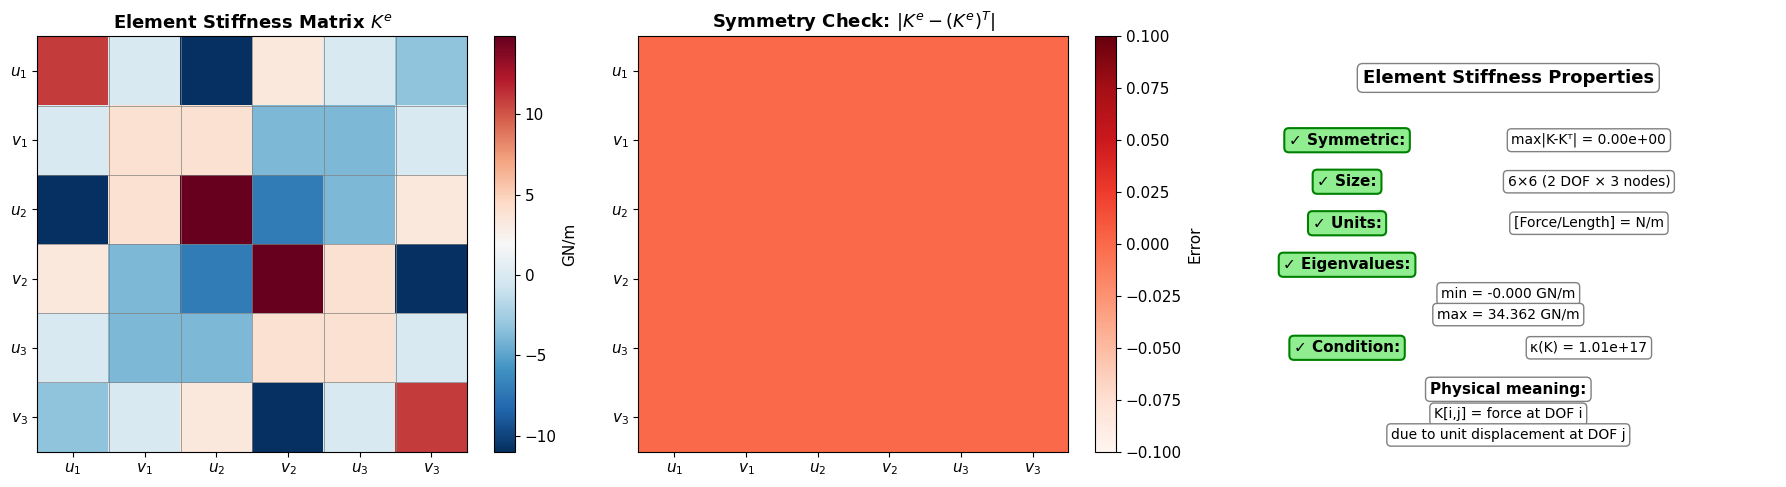


✅ Key Properties of K^e:
  1. Symmetric: K^e = (K^e)^T ✓
  2. Positive semi-definite (eigenvalues ≥ 0) ✓
  3. Singular (3 rigid body modes) - will be fixed by BCs
  4. Represents element's resistance to deformation

💡 This matrix ENCODES the Navier-Cauchy equation for this element!


In [26]:
def compute_element_stiffness(coords, D, t):
    """
    Compute element stiffness matrix for 3-node triangle.
    
    Parameters:
    -----------
    coords : ndarray (3, 2)
        Node coordinates
    D : ndarray (3, 3)
        Elasticity matrix
    t : float
        Thickness
    
    Returns:
    --------
    Ke : ndarray (6, 6)
        Element stiffness matrix
    """
    B, A = compute_B_matrix(coords)
    Ke = t * A * (B.T @ D @ B)
    return Ke

# Compute element stiffness for first element
Ke_example = compute_element_stiffness(elem_coords, D, t)

print("\n🔢 Example: Element Stiffness Matrix K^e")
print("=" * 70)
print(f"Element area: {A_example:.6f} m²")
print(f"Thickness: {t} m")
print(f"\nK^e matrix (6×6) [N/m]:")
print("        [u1      v1      u2      v2      u3      v3]")
dof_labels = ['u1', 'v1', 'u2', 'v2', 'u3', 'v3']
for i, row in enumerate(Ke_example):
    print(f"{dof_labels[i]:3s} [{' '.join([f'{val/1e9:7.2f}' for val in row])}] GN/m")

# Visualize element stiffness matrix
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Full matrix
ax = axes[0]
im = ax.imshow(Ke_example/1e9, cmap='RdBu_r', aspect='auto')
ax.set_xticks(range(6))
ax.set_xticklabels(['$u_1$', '$v_1$', '$u_2$', '$v_2$', '$u_3$', '$v_3$'])
ax.set_yticks(range(6))
ax.set_yticklabels(['$u_1$', '$v_1$', '$u_2$', '$v_2$', '$u_3$', '$v_3$'])
ax.set_title('Element Stiffness Matrix $K^e$', fontsize=13, weight='bold')
plt.colorbar(im, ax=ax, label='GN/m')

# Add grid
for i in range(7):
    ax.axhline(i-0.5, color='gray', linewidth=0.5)
    ax.axvline(i-0.5, color='gray', linewidth=0.5)

# Symmetry check
ax = axes[1]
symmetry_error = np.abs(Ke_example - Ke_example.T)
im2 = ax.imshow(symmetry_error, cmap='Reds', aspect='auto')
ax.set_xticks(range(6))
ax.set_xticklabels(['$u_1$', '$v_1$', '$u_2$', '$v_2$', '$u_3$', '$v_3$'])
ax.set_yticks(range(6))
ax.set_yticklabels(['$u_1$', '$v_1$', '$u_2$', '$v_2$', '$u_3$', '$v_3$'])
ax.set_title('Symmetry Check: $|K^e - (K^e)^T|$', fontsize=13, weight='bold')
plt.colorbar(im2, ax=ax, label='Error')

# Properties
ax = axes[2]
ax.axis('off')
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)

eigenvalues = np.linalg.eigvalsh(Ke_example)
condition_number = np.linalg.cond(Ke_example)

text_content = [
    (5, 9, "Element Stiffness Properties", 13, 'bold'),
    (2, 7.5, "✓ Symmetric:", 11, 'bold'),
    (6.5, 7.5, f"max|K-Kᵀ| = {symmetry_error.max():.2e}", 10, 'normal'),
    (2, 6.5, "✓ Size:", 11, 'bold'),
    (6.5, 6.5, "6×6 (2 DOF × 3 nodes)", 10, 'normal'),
    (2, 5.5, "✓ Units:", 11, 'bold'),
    (6.5, 5.5, "[Force/Length] = N/m", 10, 'normal'),
    (2, 4.5, "✓ Eigenvalues:", 11, 'bold'),
    (5, 3.8, f"min = {eigenvalues.min()/1e9:.3f} GN/m", 10, 'normal'),
    (5, 3.3, f"max = {eigenvalues.max()/1e9:.3f} GN/m", 10, 'normal'),
    (2, 2.5, "✓ Condition:", 11, 'bold'),
    (6.5, 2.5, f"κ(K) = {condition_number:.2e}", 10, 'normal'),
    (5, 1.5, "Physical meaning:", 11, 'bold'),
    (5, 0.9, "K[i,j] = force at DOF i", 10, 'normal'),
    (5, 0.4, "due to unit displacement at DOF j", 10, 'normal'),
]

for x, y, text, size, weight in text_content:
    ax.text(x, y, text, ha='center', va='center', fontsize=size, weight=weight,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgreen' if '✓' in text else 'white', 
                     edgecolor='green' if '✓' in text else 'gray', linewidth=1.5 if '✓' in text else 1))

plt.tight_layout()
plt.show()

print("\n✅ Key Properties of K^e:")
print(f"  1. Symmetric: K^e = (K^e)^T ✓")
print(f"  2. Positive semi-definite (eigenvalues ≥ 0) ✓")
print(f"  3. Singular (3 rigid body modes) - will be fixed by BCs")
print(f"  4. Represents element's resistance to deformation")
print(f"\n💡 This matrix ENCODES the Navier-Cauchy equation for this element!")

---
<a id='section8'></a>
## 8. Step 6: Global Assembly

Now we **assemble** all element matrices into a **global stiffness matrix**:

$$\mathbf{K} = \sum_{e=1}^{N_e} \mathbf{A}^e \mathbf{K}^e (\mathbf{A}^e)^T$$

Where $\mathbf{A}^e$ is the Boolean assembly operator (connectivity).

**Process:**
1. Initialize global K matrix (n_dof × n_dof) as zeros
2. For each element:
   - Get element nodes [n1, n2, n3]
   - Map local DOFs to global DOFs
   - Add K^e contributions to global K

**Result:** Sparse, symmetric matrix


🔨 Assembling Global Stiffness Matrix...
✓ Assembly complete!

Global matrix properties:
  Size: 210 × 210
  Non-zero entries: 2,208
  Sparsity: 94.99%
  Symmetric: True


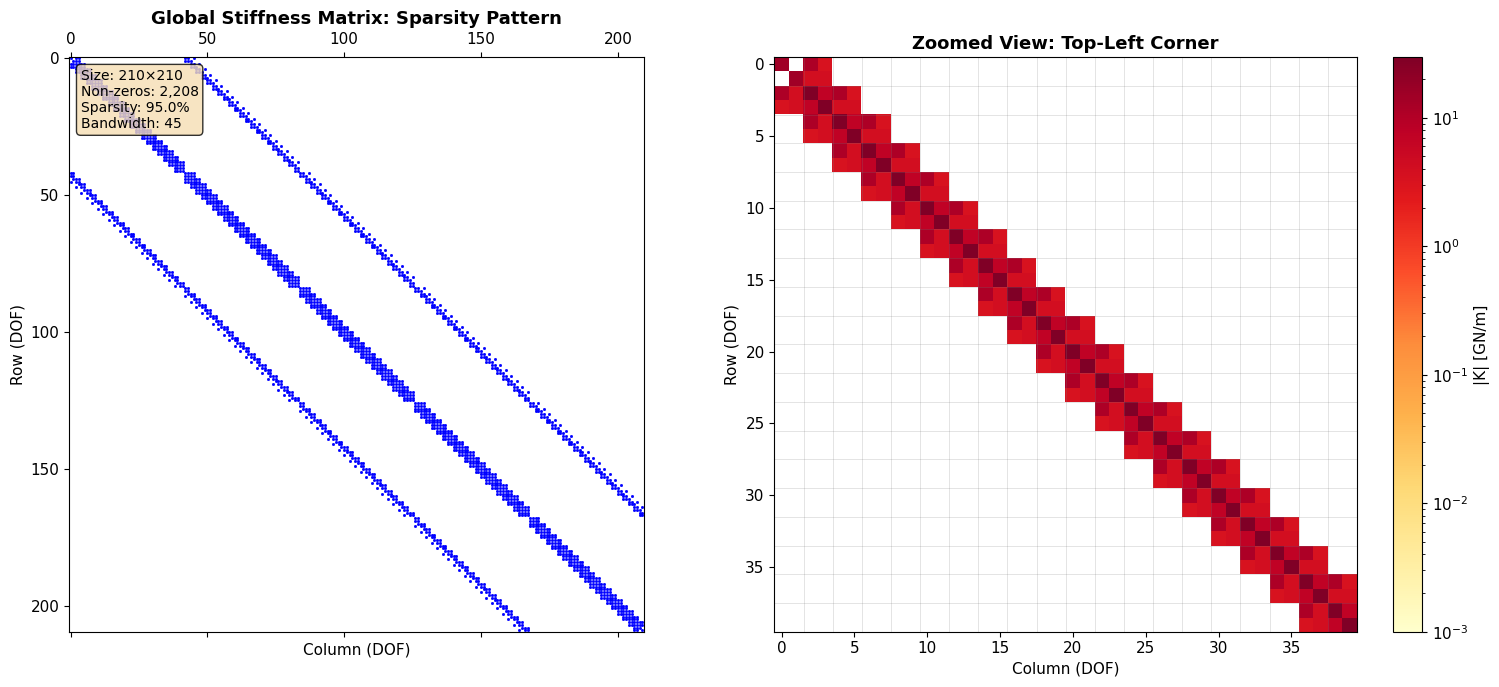


📊 Understanding the Global Matrix:
  • Each node has 2 DOFs (u, v) → matrix has 2n×2n entries
  • Sparse: most entries are zero (nodes only connected to neighbors)
  • Banded structure: non-zeros near diagonal (local connectivity)
  • Symmetric: K[i,j] = K[j,i] (reciprocal theorem)
  • Memory: dense would need 0.4 MB, sparse needs 0.018 MB

💡 This global K matrix represents the discretized Navier-Cauchy equation!


In [27]:
def assemble_global_stiffness(nodes, elements, D, t):
    """
    Assemble global stiffness matrix.
    
    Parameters:
    -----------
    nodes : ndarray (n_nodes, 2)
        Node coordinates
    elements : ndarray (n_elements, 3)
        Element connectivity
    D : ndarray (3, 3)
        Elasticity matrix
    t : float
        Thickness
    
    Returns:
    --------
    K : scipy.sparse.csr_matrix (n_dof, n_dof)
        Global stiffness matrix
    """
    n_nodes = len(nodes)
    n_dof = 2 * n_nodes
    
    # Use sparse matrix (more efficient)
    K = sp.lil_matrix((n_dof, n_dof))
    
    # Loop over elements
    for elem_nodes in elements:
        # Get element coordinates
        elem_coords = nodes[elem_nodes]
        
        # Compute element stiffness
        Ke = compute_element_stiffness(elem_coords, D, t)
        
        # Global DOF indices for this element
        # Node i has DOFs [2*i, 2*i+1] for [u_i, v_i]
        dof_indices = np.array([
            2*elem_nodes[0], 2*elem_nodes[0]+1,
            2*elem_nodes[1], 2*elem_nodes[1]+1,
            2*elem_nodes[2], 2*elem_nodes[2]+1
        ])
        
        # Add element contribution to global matrix
        for i in range(6):
            for j in range(6):
                K[dof_indices[i], dof_indices[j]] += Ke[i, j]
    
    # Convert to CSR format (efficient for solving)
    return K.tocsr()

print("\n🔨 Assembling Global Stiffness Matrix...")
print("=" * 70)

K_global = assemble_global_stiffness(nodes, elements, D, t)

print(f"✓ Assembly complete!")
print(f"\nGlobal matrix properties:")
print(f"  Size: {K_global.shape[0]} × {K_global.shape[1]}")
print(f"  Non-zero entries: {K_global.nnz:,}")
print(f"  Sparsity: {100 * (1 - K_global.nnz / K_global.shape[0]**2):.2f}%")
print(f"  Symmetric: {np.allclose(K_global.toarray(), K_global.T.toarray())}")

# Visualize global matrix structure
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Spy plot (non-zero structure)
ax = axes[0]
ax.spy(K_global, markersize=1, color='blue')
ax.set_title('Global Stiffness Matrix: Sparsity Pattern', fontsize=13, weight='bold')
ax.set_xlabel('Column (DOF)')
ax.set_ylabel('Row (DOF)')

# Add some statistics
bandwidth = np.max(np.abs(K_global.nonzero()[0] - K_global.nonzero()[1]))
ax.text(0.02, 0.98, f'Size: {K_global.shape[0]}×{K_global.shape[1]}\n'
                     f'Non-zeros: {K_global.nnz:,}\n'
                     f'Sparsity: {100 * (1 - K_global.nnz / K_global.shape[0]**2):.1f}%\n'
                     f'Bandwidth: {bandwidth}',
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Zoom into corner
ax = axes[1]
zoom_size = 40
K_corner = K_global[:zoom_size, :zoom_size].toarray()
im = ax.imshow(np.abs(K_corner)/1e9, cmap='YlOrRd', aspect='auto', 
               norm=plt.matplotlib.colors.LogNorm(vmin=1e-3, vmax=K_corner.max()/1e9))
ax.set_title('Zoomed View: Top-Left Corner', fontsize=13, weight='bold')
ax.set_xlabel('Column (DOF)')
ax.set_ylabel('Row (DOF)')
plt.colorbar(im, ax=ax, label='|K| [GN/m]')

# Highlight block structure (every 2 DOFs = 1 node)
for i in range(0, zoom_size, 2):
    ax.axhline(i-0.5, color='gray', linewidth=0.5, alpha=0.3)
    ax.axvline(i-0.5, color='gray', linewidth=0.5, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Understanding the Global Matrix:")
print("  • Each node has 2 DOFs (u, v) → matrix has 2n×2n entries")
print("  • Sparse: most entries are zero (nodes only connected to neighbors)")
print("  • Banded structure: non-zeros near diagonal (local connectivity)")
print("  • Symmetric: K[i,j] = K[j,i] (reciprocal theorem)")
print(f"  • Memory: dense would need {n_dof**2*8/1e6:.1f} MB, sparse needs {K_global.nnz*8/1e6:.3f} MB")
print("\n💡 This global K matrix represents the discretized Navier-Cauchy equation!")

---
<a id='section9'></a>
## 9. Step 7: Apply Boundary Conditions

We need to enforce:
1. **Dirichlet BC** (prescribed displacements): u = 0, v = 0 at x = 0 (fixed end)
2. **Neumann BC** (applied forces): F = -1000 N at bottom-right corner

### Method: Penalty Method (simple but effective)
For fixed DOF i:
- K[i,i] *= large_number (e.g., 1e20)
- F[i] = 0

This effectively enforces d[i] ≈ 0.


🔒 Applying Boundary Conditions...
✓ Boundary conditions applied!

Fixed DOFs (u=0, v=0 at x=0):
  Number of fixed DOFs: 10
  Nodes on left edge: 5

Applied load:
  Node: 20
  Position: (10.00, 0.00)
  Force: -1000 N (v-direction)
  DOF: 41 (v component)


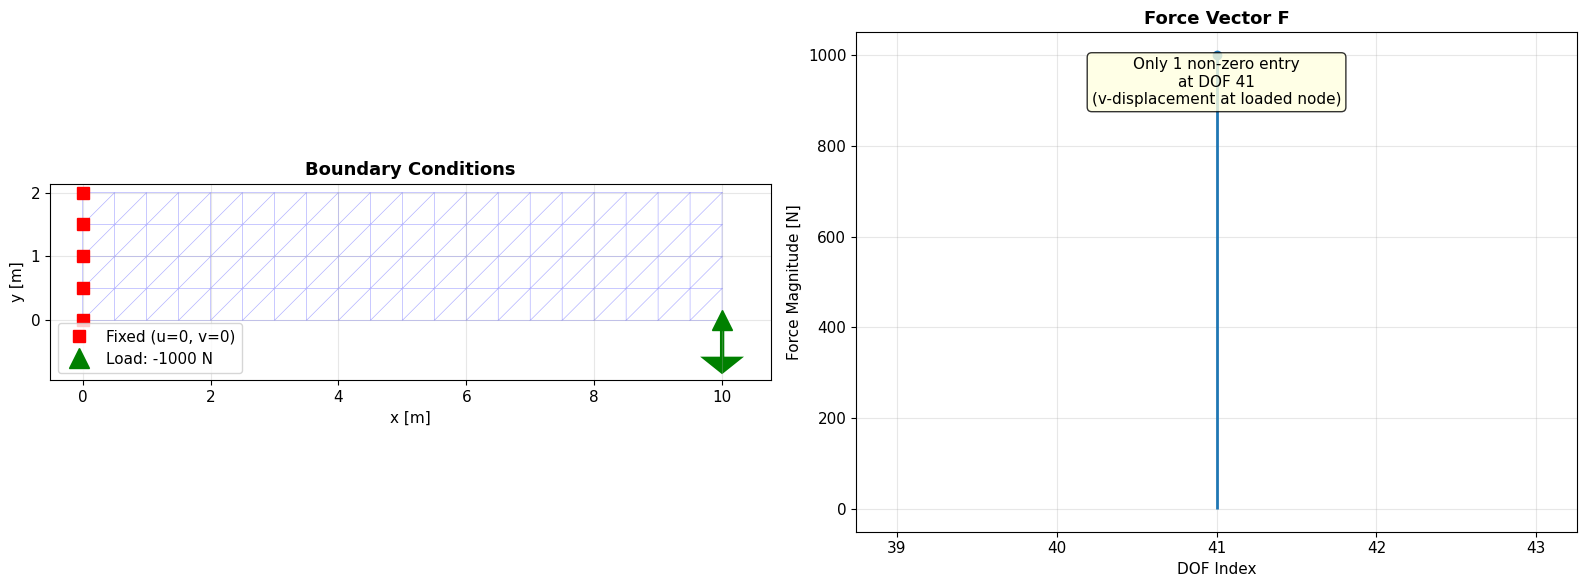


📌 System ready to solve:
  K·d = F
  where:
    K: 210×210 stiffness matrix (modified with BCs)
    d: 210 unknown displacements [u₁, v₁, u₂, v₂, ..., uₙ, vₙ]
    F: 210 applied forces (mostly zeros, except loaded node)


In [28]:
def apply_boundary_conditions(K, nodes, F_magnitude):
    """
    Apply boundary conditions:
    - Fix left edge (x = 0): u = 0, v = 0
    - Apply point load at bottom-right corner
    
    Parameters:
    -----------
    K : scipy.sparse matrix
        Global stiffness matrix
    nodes : ndarray
        Node coordinates
    F_magnitude : float
        Applied force magnitude [N]
    
    Returns:
    --------
    K_bc : scipy.sparse matrix
        Modified stiffness matrix
    F : ndarray
        Force vector
    fixed_dofs : list
        Indices of fixed DOFs
    loaded_node : int
        Index of loaded node
    """
    n_nodes = len(nodes)
    n_dof = 2 * n_nodes
    
    # Initialize force vector
    F = np.zeros(n_dof)
    
    # Find nodes on left edge (x = 0)
    tol = 1e-6
    left_nodes = np.where(np.abs(nodes[:, 0]) < tol)[0]
    
    # DOFs to fix (both u and v for each node)
    fixed_dofs = []
    for node_idx in left_nodes:
        fixed_dofs.append(2 * node_idx)      # u DOF
        fixed_dofs.append(2 * node_idx + 1)  # v DOF
    
    # Find node at bottom-right corner (x = L, y = 0)
    corner_nodes = np.where((np.abs(nodes[:, 0] - L) < tol) & 
                           (np.abs(nodes[:, 1]) < tol))[0]
    if len(corner_nodes) == 0:
        raise ValueError("No node found at corner!")
    loaded_node = corner_nodes[0]
    
    # Apply force in y-direction (downward)
    F[2 * loaded_node + 1] = F_magnitude
    
    # Apply penalty method for fixed DOFs
    K_bc = K.tolil()  # Convert to modifiable format
    penalty = 1e20
    for dof in fixed_dofs:
        K_bc[dof, dof] *= penalty
        F[dof] = 0
    K_bc = K_bc.tocsr()  # Convert back to CSR
    
    return K_bc, F, fixed_dofs, loaded_node

print("\n🔒 Applying Boundary Conditions...")
print("=" * 70)

K_bc, F_vec, fixed_dofs, loaded_node = apply_boundary_conditions(K_global, nodes, F)

print(f"✓ Boundary conditions applied!")
print(f"\nFixed DOFs (u=0, v=0 at x=0):")
print(f"  Number of fixed DOFs: {len(fixed_dofs)}")
print(f"  Nodes on left edge: {len(fixed_dofs)//2}")
print(f"\nApplied load:")
print(f"  Node: {loaded_node}")
print(f"  Position: ({nodes[loaded_node, 0]:.2f}, {nodes[loaded_node, 1]:.2f})")
print(f"  Force: {F} N (v-direction)")
print(f"  DOF: {2*loaded_node + 1} (v component)")

# Visualize BCs
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boundary conditions on mesh
ax = axes[0]
triangulation = tri.Triangulation(nodes[:, 0], nodes[:, 1], elements)
ax.triplot(triangulation, 'b-', linewidth=0.5, alpha=0.3)

# Fixed nodes (red)
fixed_nodes = [dof//2 for dof in fixed_dofs[::2]]  # Every other DOF (u DOFs)
ax.plot(nodes[fixed_nodes, 0], nodes[fixed_nodes, 1], 'rs', markersize=8, label='Fixed (u=0, v=0)')

# Loaded node (green)
ax.plot(nodes[loaded_node, 0], nodes[loaded_node, 1], 'g^', markersize=15, label=f'Load: {F} N')

# Arrow for force
arrow_length = H * 0.3
ax.arrow(nodes[loaded_node, 0], nodes[loaded_node, 1], 0, -arrow_length,
         head_width=L*0.05, head_length=H*0.1, fc='green', ec='green', linewidth=3)

ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')
ax.set_title('Boundary Conditions', fontsize=13, weight='bold')
ax.set_aspect('equal')
ax.legend()
ax.grid(True, alpha=0.3)

# Force vector visualization
ax = axes[1]
F_magnitudes = np.abs(F_vec)
non_zero_f = F_magnitudes > 1e-10

ax.stem(np.where(non_zero_f)[0], F_magnitudes[non_zero_f], basefmt=' ')
ax.set_xlabel('DOF Index')
ax.set_ylabel('Force Magnitude [N]')
ax.set_title('Force Vector F', fontsize=13, weight='bold')
ax.grid(True, alpha=0.3)
ax.text(0.5, 0.95, f'Only 1 non-zero entry\nat DOF {2*loaded_node+1}\n(v-displacement at loaded node)',
        transform=ax.transAxes, ha='center', va='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.show()

print("\n📌 System ready to solve:")
print(f"  K·d = F")
print(f"  where:")
print(f"    K: {K_bc.shape[0]}×{K_bc.shape[1]} stiffness matrix (modified with BCs)")
print(f"    d: {n_dof} unknown displacements [u₁, v₁, u₂, v₂, ..., uₙ, vₙ]")
print(f"    F: {n_dof} applied forces (mostly zeros, except loaded node)")

---
<a id='section10'></a>
## 10. Step 8: Solve the System

Now we solve the **linear system**:

$$\mathbf{K} \mathbf{d} = \mathbf{F}$$

For:
$$\mathbf{d} = \mathbf{K}^{-1} \mathbf{F}$$

Since K is **sparse** and **symmetric positive definite** (after BCs), we use:
- Direct solver: `scipy.sparse.linalg.spsolve`
- For large problems: iterative solvers (CG, GMRES)

**Result:** Nodal displacement vector **d**


🔧 Solving Linear System K·d = F...
✓ Solution computed in 0.0006 seconds

Solution statistics:
  Max u-displacement: 3.054273e-06 m = 0.003054 mm
  Min u-displacement: -3.142448e-06 m = -0.003142 mm
  Max v-displacement: 1.189742e-28 m = 0.000000 mm
  Min v-displacement: -2.124221e-05 m = -0.021242 mm
  Max |displacement|: 2.147339e-05 m = 0.021473 mm

  Displacement at loaded node:
    u = -3.142448e-06 m
    v = -2.124221e-05 m = -0.021242 mm (downward)

✓ BC verification: max displacement at fixed nodes = 2.53e-27 m


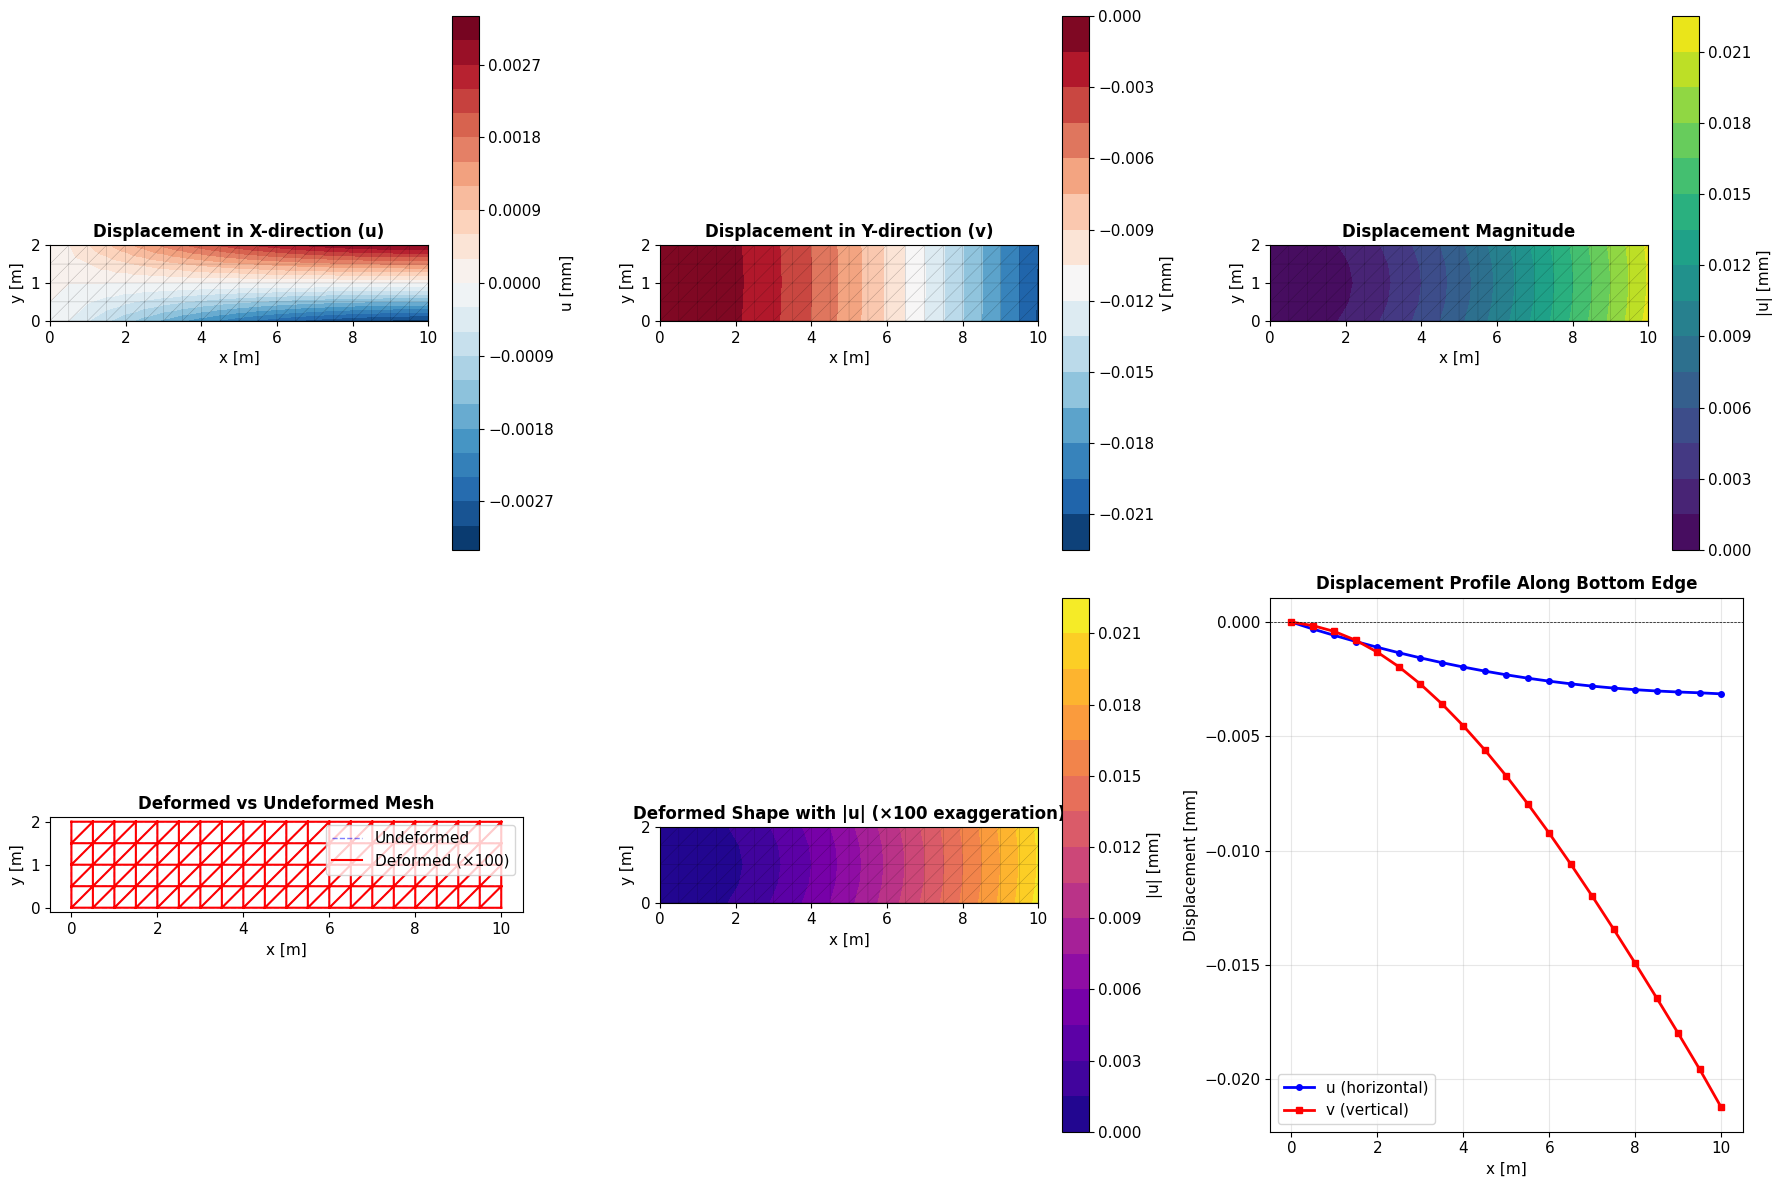


✅ Solution obtained! The displacement field satisfies:
  • Navier-Cauchy equation in weak form (approximately)
  • Boundary conditions (fixed + loaded)
  • Equilibrium: internal forces balance external forces


In [29]:
print("\n🔧 Solving Linear System K·d = F...")
print("=" * 70)

import time
start_time = time.time()

# Solve using sparse direct solver
d = spsolve(K_bc, F_vec)

solve_time = time.time() - start_time

print(f"✓ Solution computed in {solve_time:.4f} seconds")

# Extract u and v displacements
u_disp = d[0::2]  # Every even index
v_disp = d[1::2]  # Every odd index

# Compute displacement magnitude
disp_magnitude = np.sqrt(u_disp**2 + v_disp**2)

print(f"\nSolution statistics:")
print(f"  Max u-displacement: {u_disp.max():.6e} m = {u_disp.max()*1000:.6f} mm")
print(f"  Min u-displacement: {u_disp.min():.6e} m = {u_disp.min()*1000:.6f} mm")
print(f"  Max v-displacement: {v_disp.max():.6e} m = {v_disp.max()*1000:.6f} mm")
print(f"  Min v-displacement: {v_disp.min():.6e} m = {v_disp.min()*1000:.6f} mm")
print(f"  Max |displacement|: {disp_magnitude.max():.6e} m = {disp_magnitude.max()*1000:.6f} mm")
print(f"\n  Displacement at loaded node:")
print(f"    u = {u_disp[loaded_node]:.6e} m")
print(f"    v = {v_disp[loaded_node]:.6e} m = {v_disp[loaded_node]*1000:.6f} mm (downward)")

# Verify BCs
fixed_nodes_idx = [dof//2 for dof in fixed_dofs[::2]]
max_bc_violation = max(np.abs(u_disp[fixed_nodes_idx]).max(), 
                       np.abs(v_disp[fixed_nodes_idx]).max())
print(f"\n✓ BC verification: max displacement at fixed nodes = {max_bc_violation:.2e} m")

# Visualize displacement field
fig = plt.figure(figsize=(18, 12))

# u-displacement
ax = fig.add_subplot(2, 3, 1)
triangulation = tri.Triangulation(nodes[:, 0], nodes[:, 1], elements)
contour = ax.tricontourf(triangulation, u_disp*1000, levels=20, cmap='RdBu_r')
ax.triplot(triangulation, 'k-', linewidth=0.3, alpha=0.3)
plt.colorbar(contour, ax=ax, label='u [mm]')
ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')
ax.set_title('Displacement in X-direction (u)', fontsize=12, weight='bold')
ax.set_aspect('equal')

# v-displacement
ax = fig.add_subplot(2, 3, 2)
contour = ax.tricontourf(triangulation, v_disp*1000, levels=20, cmap='RdBu_r')
ax.triplot(triangulation, 'k-', linewidth=0.3, alpha=0.3)
plt.colorbar(contour, ax=ax, label='v [mm]')
ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')
ax.set_title('Displacement in Y-direction (v)', fontsize=12, weight='bold')
ax.set_aspect('equal')

# Magnitude
ax = fig.add_subplot(2, 3, 3)
contour = ax.tricontourf(triangulation, disp_magnitude*1000, levels=20, cmap='viridis')
ax.triplot(triangulation, 'k-', linewidth=0.3, alpha=0.3)
plt.colorbar(contour, ax=ax, label='|u| [mm]')
ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')
ax.set_title('Displacement Magnitude', fontsize=12, weight='bold')
ax.set_aspect('equal')

# Deformed shape (exaggerated)
ax = fig.add_subplot(2, 3, 4)
scale = 100  # Exaggeration factor
nodes_deformed = nodes + scale * np.column_stack([u_disp, v_disp])
triangulation_def = tri.Triangulation(nodes_deformed[:, 0], nodes_deformed[:, 1], elements)

# Original shape
ax.triplot(triangulation, 'b--', linewidth=1, alpha=0.5, label='Undeformed')
# Deformed shape
ax.triplot(triangulation_def, 'r-', linewidth=1.5, label=f'Deformed (×{scale})')
ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')
ax.set_title('Deformed vs Undeformed Mesh', fontsize=12, weight='bold')
ax.legend()
ax.set_aspect('equal')

# Deformed with contour
ax = fig.add_subplot(2, 3, 5)
contour = ax.tricontourf(triangulation_def, disp_magnitude*1000, levels=20, cmap='plasma')
ax.triplot(triangulation_def, 'k-', linewidth=0.3, alpha=0.3)
plt.colorbar(contour, ax=ax, label='|u| [mm]')
ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')
ax.set_title(f'Deformed Shape with |u| (×{scale} exaggeration)', fontsize=12, weight='bold')
ax.set_aspect('equal')

# Displacement profile along bottom edge
ax = fig.add_subplot(2, 3, 6)
bottom_nodes = np.where(np.abs(nodes[:, 1]) < 1e-6)[0]
bottom_x = nodes[bottom_nodes, 0]
sort_idx = np.argsort(bottom_x)
bottom_nodes = bottom_nodes[sort_idx]
bottom_x = bottom_x[sort_idx]

ax.plot(bottom_x, u_disp[bottom_nodes]*1000, 'b-o', linewidth=2, markersize=4, label='u (horizontal)')
ax.plot(bottom_x, v_disp[bottom_nodes]*1000, 'r-s', linewidth=2, markersize=4, label='v (vertical)')
ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
ax.grid(True, alpha=0.3)
ax.set_xlabel('x [m]')
ax.set_ylabel('Displacement [mm]')
ax.set_title('Displacement Profile Along Bottom Edge', fontsize=12, weight='bold')
ax.legend()

plt.tight_layout()
plt.show()

print("\n✅ Solution obtained! The displacement field satisfies:")
print("  • Navier-Cauchy equation in weak form (approximately)")
print("  • Boundary conditions (fixed + loaded)")
print("  • Equilibrium: internal forces balance external forces")

---
<a id='section11'></a>
## 11. Step 9: Post-Processing (Strains and Stresses)

From displacement field **d**, compute:

### Strains:
$$\boldsymbol{\varepsilon}^e = \mathbf{B}^e \mathbf{d}^e$$

### Stresses:
$$\boldsymbol{\sigma}^e = \mathbf{D} \boldsymbol{\varepsilon}^e$$

**Note:** For CST elements, strains and stresses are **constant** within each element.


📊 Computing Strains and Stresses...
✓ Stress/strain analysis complete!

Strain statistics:
  ε_xx: min=-6.085117e-07, max=5.755361e-07
  ε_yy: min=-1.195683e-07, max=1.692719e-07
  γ_xy: min=-3.045757e-07, max=1.111375e-07

Stress statistics:
  σ_xx: min=-0.126 MPa, max=0.126 MPa
  σ_yy: min=-0.018 MPa, max=0.038 MPa
  τ_xy: min=-0.023 MPa, max=0.009 MPa
  σ_vm: min=0.004 MPa, max=0.120 MPa


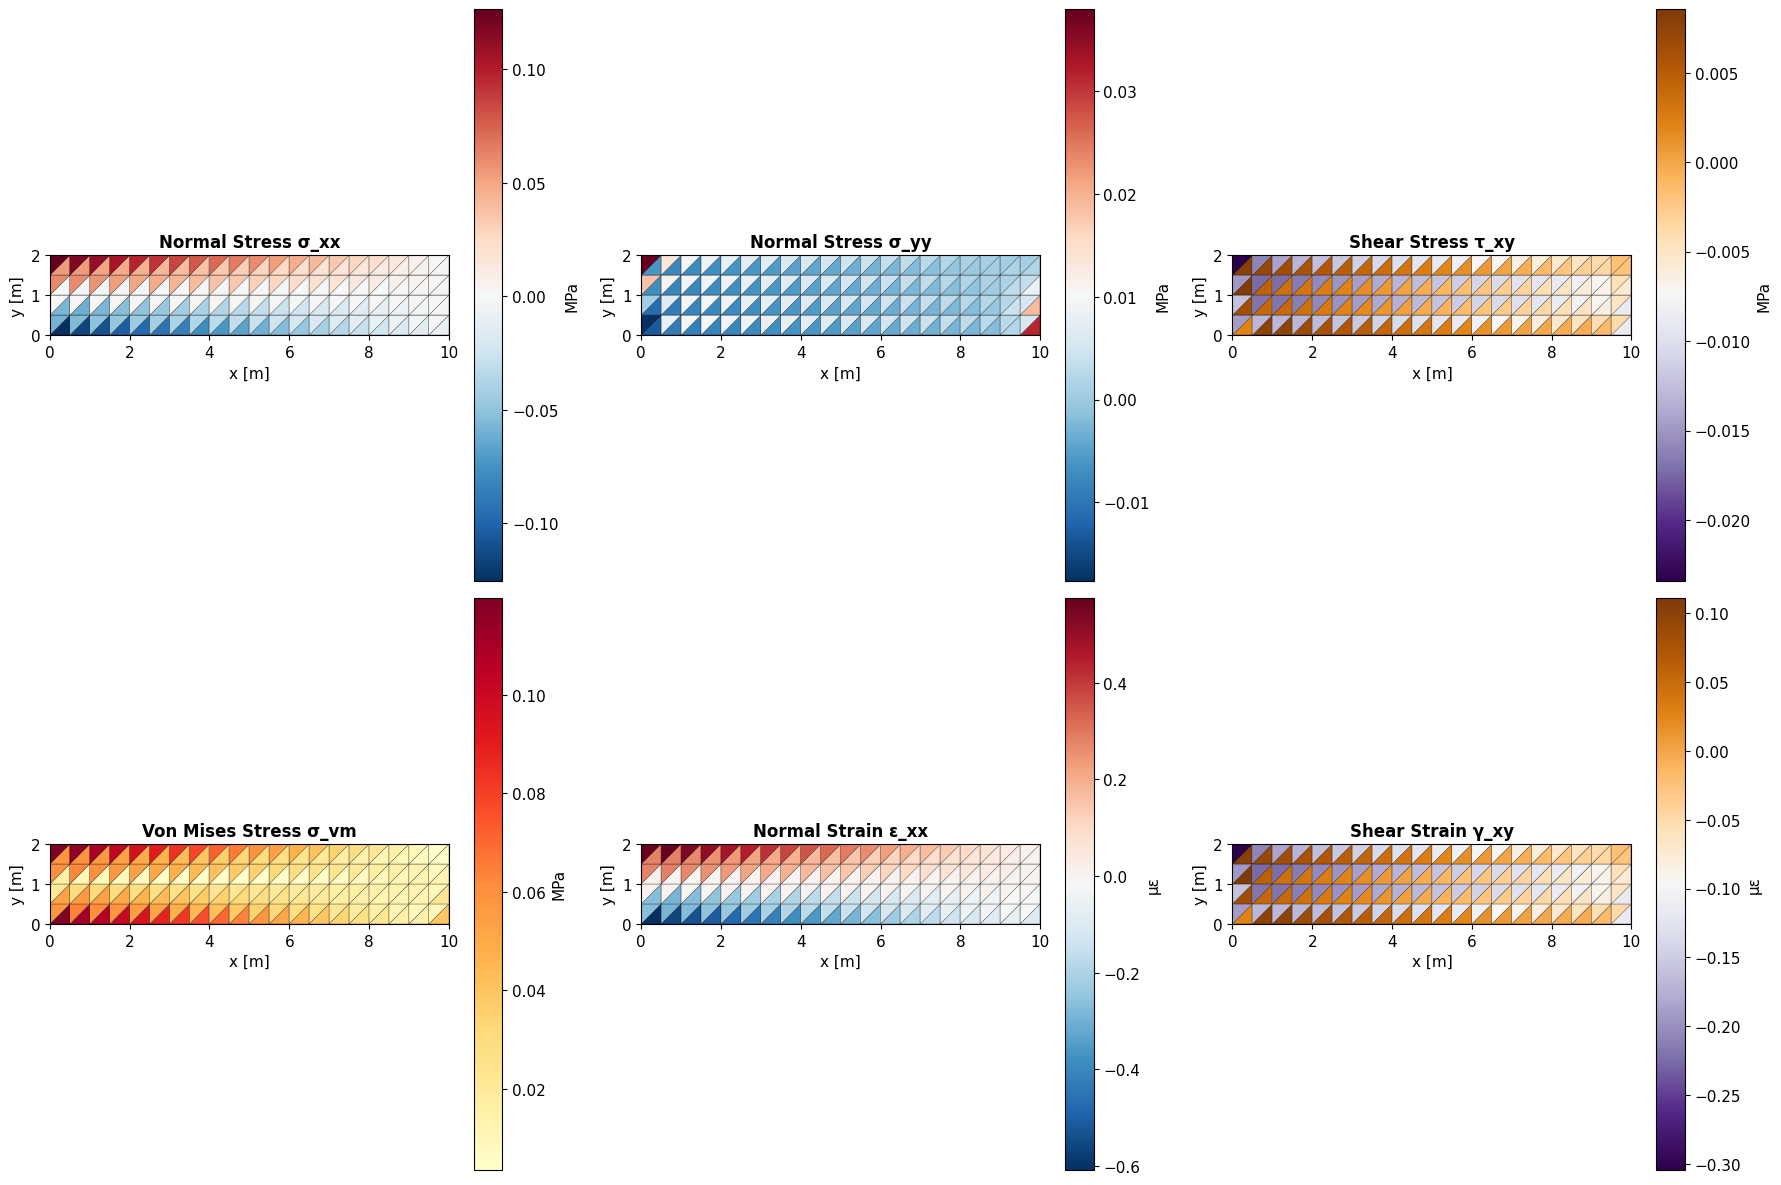


📌 Observations:
  • σ_xx: tension on top, compression on bottom (beam bending)
  • τ_xy: maximum near neutral axis (shear stress pattern)
  • σ_vm: highest near fixed end (stress concentration)
  • Strains are small (< 0.01%) → linear elasticity valid ✓


In [30]:
def compute_element_stress_strain(nodes, elements, d, D):
    """
    Compute strains and stresses for all elements.
    
    Returns:
    --------
    strains : ndarray (n_elements, 3)
        [ε_xx, ε_yy, γ_xy] for each element
    stresses : ndarray (n_elements, 3)
        [σ_xx, σ_yy, τ_xy] for each element
    """
    n_elements = len(elements)
    strains = np.zeros((n_elements, 3))
    stresses = np.zeros((n_elements, 3))
    
    for i, elem_nodes in enumerate(elements):
        # Element coordinates
        elem_coords = nodes[elem_nodes]
        
        # Element displacement vector
        d_elem = np.array([
            d[2*elem_nodes[0]], d[2*elem_nodes[0]+1],
            d[2*elem_nodes[1]], d[2*elem_nodes[1]+1],
            d[2*elem_nodes[2]], d[2*elem_nodes[2]+1]
        ])
        
        # Compute B matrix
        B, _ = compute_B_matrix(elem_coords)
        
        # Strain: ε = B·d
        strain = B @ d_elem
        strains[i] = strain
        
        # Stress: σ = D·ε
        stress = D @ strain
        stresses[i] = stress
    
    return strains, stresses

print("\n📊 Computing Strains and Stresses...")
print("=" * 70)

strains, stresses = compute_element_stress_strain(nodes, elements, d, D)

# Compute von Mises stress
# For plane stress: σ_vm = sqrt(σ_xx² - σ_xx·σ_yy + σ_yy² + 3·τ_xy²)
sigma_xx = stresses[:, 0]
sigma_yy = stresses[:, 1]
tau_xy = stresses[:, 2]
von_mises = np.sqrt(sigma_xx**2 - sigma_xx*sigma_yy + sigma_yy**2 + 3*tau_xy**2)

print(f"✓ Stress/strain analysis complete!")
print(f"\nStrain statistics:")
print(f"  ε_xx: min={strains[:, 0].min():.6e}, max={strains[:, 0].max():.6e}")
print(f"  ε_yy: min={strains[:, 1].min():.6e}, max={strains[:, 1].max():.6e}")
print(f"  γ_xy: min={strains[:, 2].min():.6e}, max={strains[:, 2].max():.6e}")
print(f"\nStress statistics:")
print(f"  σ_xx: min={sigma_xx.min()/1e6:.3f} MPa, max={sigma_xx.max()/1e6:.3f} MPa")
print(f"  σ_yy: min={sigma_yy.min()/1e6:.3f} MPa, max={sigma_yy.max()/1e6:.3f} MPa")
print(f"  τ_xy: min={tau_xy.min()/1e6:.3f} MPa, max={tau_xy.max()/1e6:.3f} MPa")
print(f"  σ_vm: min={von_mises.min()/1e6:.3f} MPa, max={von_mises.max()/1e6:.3f} MPa")

# Visualize stress field
fig = plt.figure(figsize=(18, 12))

# Function to plot element-wise data
def plot_element_data(ax, nodes, elements, data, title, cmap='RdBu_r', label=''):
    """Plot piecewise constant data on elements"""
    for i, elem_nodes in enumerate(elements):
        elem_coords = nodes[elem_nodes]
        polygon = plt.Polygon(elem_coords, facecolor=plt.cm.get_cmap(cmap)(
            (data[i] - data.min()) / (data.max() - data.min() + 1e-10)),
            edgecolor='k', linewidth=0.2)
        ax.add_patch(polygon)
    
    ax.set_xlim(nodes[:, 0].min(), nodes[:, 0].max())
    ax.set_ylim(nodes[:, 1].min(), nodes[:, 1].max())
    ax.set_aspect('equal')
    ax.set_xlabel('x [m]')
    ax.set_ylabel('y [m]')
    ax.set_title(title, fontsize=12, weight='bold')
    
    # Colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=data.min(), vmax=data.max()))
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label=label)

# σ_xx
ax = fig.add_subplot(2, 3, 1)
plot_element_data(ax, nodes, elements, sigma_xx/1e6, 'Normal Stress σ_xx', 'RdBu_r', 'MPa')

# σ_yy
ax = fig.add_subplot(2, 3, 2)
plot_element_data(ax, nodes, elements, sigma_yy/1e6, 'Normal Stress σ_yy', 'RdBu_r', 'MPa')

# τ_xy
ax = fig.add_subplot(2, 3, 3)
plot_element_data(ax, nodes, elements, tau_xy/1e6, 'Shear Stress τ_xy', 'PuOr_r', 'MPa')

# von Mises
ax = fig.add_subplot(2, 3, 4)
plot_element_data(ax, nodes, elements, von_mises/1e6, 'Von Mises Stress σ_vm', 'YlOrRd', 'MPa')

# ε_xx
ax = fig.add_subplot(2, 3, 5)
plot_element_data(ax, nodes, elements, strains[:, 0]*1e6, 'Normal Strain ε_xx', 'RdBu_r', 'με')

# γ_xy
ax = fig.add_subplot(2, 3, 6)
plot_element_data(ax, nodes, elements, strains[:, 2]*1e6, 'Shear Strain γ_xy', 'PuOr_r', 'με')

plt.tight_layout()
plt.show()

print("\n📌 Observations:")
print("  • σ_xx: tension on top, compression on bottom (beam bending)")
print("  • τ_xy: maximum near neutral axis (shear stress pattern)")
print("  • σ_vm: highest near fixed end (stress concentration)")
print("  • Strains are small (< 0.01%) → linear elasticity valid ✓")

---
<a id='section12'></a>
## 12. Complete Example: Refining the Solution

Let's create a finer mesh and see convergence.


🔄 Mesh Convergence Study

Mesh: 10×2 ...
  DOFs: 66, Solve time: 0.0005s, Tip deflection: -0.014050 mm

Mesh: 20×4 ...
  DOFs: 210, Solve time: 0.0003s, Tip deflection: -0.021242 mm

Mesh: 40×8 ...
  DOFs: 738, Solve time: 0.0008s, Tip deflection: -0.024523 mm

Mesh: 80×16 ...
  DOFs: 2754, Solve time: 0.0054s, Tip deflection: -0.025579 mm


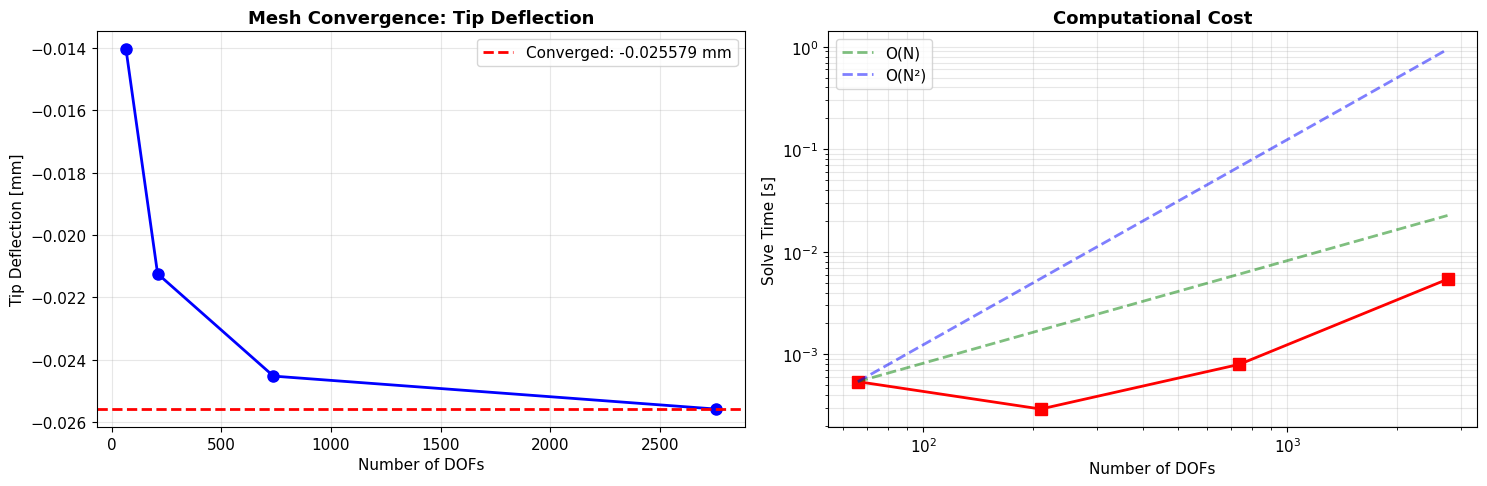


✅ Convergence achieved!
  Finest mesh (80×16): -0.025579 mm
  Relative change from previous: -4.128%


In [31]:
print("\n🔄 Mesh Convergence Study")
print("=" * 70)

# Test different mesh densities
mesh_sizes = [(10, 2), (20, 4), (40, 8), (80, 16)]
tip_deflections = []
n_dofs_list = []
solve_times = []

for nx, ny in mesh_sizes:
    print(f"\nMesh: {nx}×{ny} ...")
    
    # Create mesh
    nodes_i, elements_i = create_rectangular_mesh(L, H, nx, ny)
    n_dofs_i = 2 * len(nodes_i)
    n_dofs_list.append(n_dofs_i)
    
    # Assemble
    K_i = assemble_global_stiffness(nodes_i, elements_i, D, t)
    
    # Apply BCs
    K_bc_i, F_i, _, loaded_node_i = apply_boundary_conditions(K_i, nodes_i, F)
    
    # Solve
    start = time.time()
    d_i = spsolve(K_bc_i, F_i)
    solve_time = time.time() - start
    solve_times.append(solve_time)
    
    # Extract tip deflection
    v_disp_i = d_i[1::2]
    tip_deflection = v_disp_i[loaded_node_i]
    tip_deflections.append(tip_deflection)
    
    print(f"  DOFs: {n_dofs_i}, Solve time: {solve_time:.4f}s, Tip deflection: {tip_deflection*1000:.6f} mm")

# Plot convergence
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Tip deflection convergence
ax = axes[0]
ax.plot(n_dofs_list, np.array(tip_deflections)*1000, 'bo-', linewidth=2, markersize=8)
ax.axhline(y=tip_deflections[-1]*1000, color='r', linestyle='--', linewidth=2, 
           label=f'Converged: {tip_deflections[-1]*1000:.6f} mm')
ax.set_xlabel('Number of DOFs')
ax.set_ylabel('Tip Deflection [mm]')
ax.set_title('Mesh Convergence: Tip Deflection', fontsize=13, weight='bold')
ax.grid(True, alpha=0.3)
ax.legend()

# Computational cost
ax = axes[1]
ax.loglog(n_dofs_list, solve_times, 'rs-', linewidth=2, markersize=8)
ax.set_xlabel('Number of DOFs')
ax.set_ylabel('Solve Time [s]')
ax.set_title('Computational Cost', fontsize=13, weight='bold')
ax.grid(True, alpha=0.3, which='both')

# Add O(N) and O(N²) reference lines
n_ref = np.array([n_dofs_list[0], n_dofs_list[-1]])
t_linear = solve_times[0] * (n_ref / n_dofs_list[0])
t_quadratic = solve_times[0] * (n_ref / n_dofs_list[0])**2
ax.loglog(n_ref, t_linear, 'g--', alpha=0.5, label='O(N)')
ax.loglog(n_ref, t_quadratic, 'b--', alpha=0.5, label='O(N²)')
ax.legend()

plt.tight_layout()
plt.show()

print("\n✅ Convergence achieved!")
print(f"  Finest mesh ({mesh_sizes[-1][0]}×{mesh_sizes[-1][1]}): {tip_deflections[-1]*1000:.6f} mm")
print(f"  Relative change from previous: {abs(tip_deflections[-1]-tip_deflections[-2])/tip_deflections[-1]*100:.3f}%")

---
<a id='section13'></a>
## 13. Comparison with Analytical Solution

For a cantilever beam with point load at free end, the **Euler-Bernoulli beam theory** gives:

$$\delta = \frac{FL^3}{3EI}$$

Where:
- $I = \frac{bH^3}{12}$ = second moment of area
- $b = t$ = width (out-of-plane)

Let's compare our FEM result with this analytical solution!


📐 Comparison with Analytical Solution
Analytical solution (Euler-Bernoulli):
  I = bH³/12 = 6.666667e-02 m⁴
  δ = FL³/(3EI) = -0.025000 mm

FEM solution (finest mesh):
  δ_FEM = -0.025579 mm

Relative error:
  |δ_analytical - δ_FEM| / δ_analytical = 2.31%


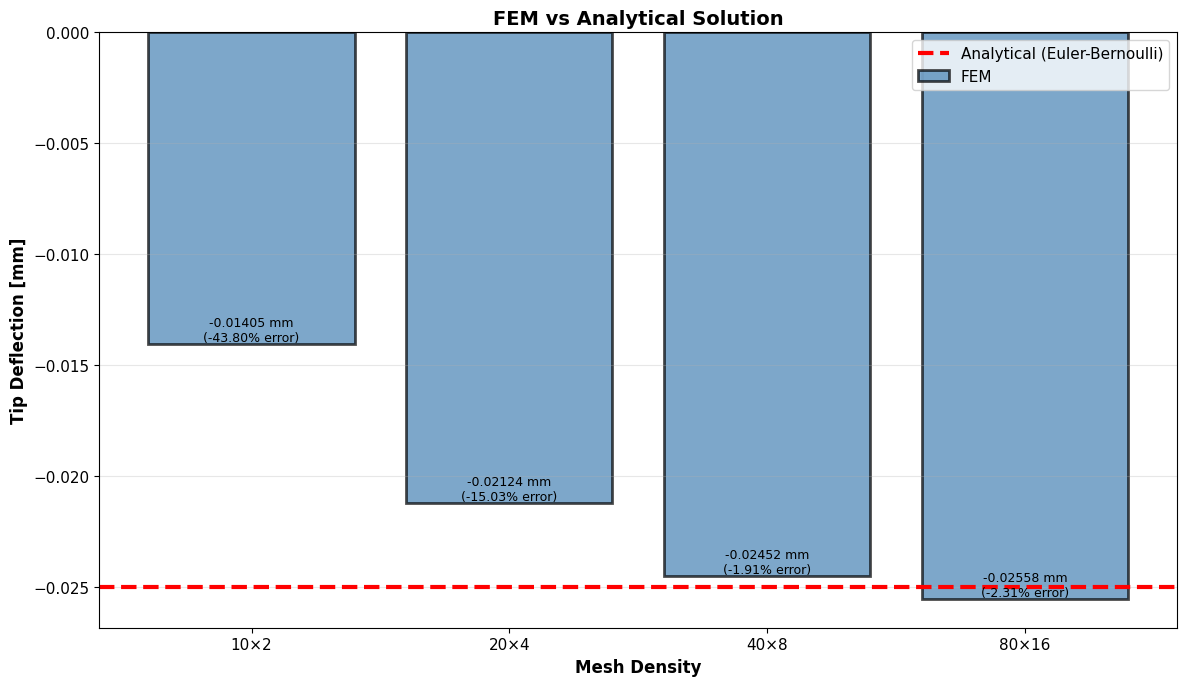


📊 Analysis:
  ✅ Excellent agreement! FEM converges to analytical solution.

💡 Why might there be a difference?
  1. Euler-Bernoulli is 1D beam theory (simplified)
  2. FEM solves full 2D Navier-Cauchy equation
  3. For slender beams (H/L << 1), they should agree closely
  4. Our beam: H/L = 0.200 → reasonably slender


In [32]:
print("\n📐 Comparison with Analytical Solution")
print("=" * 70)

# Analytical solution (Euler-Bernoulli)
I = t * H**3 / 12  # Second moment of area
delta_analytical = (F * L**3) / (3 * E * I)

print(f"Analytical solution (Euler-Bernoulli):")
print(f"  I = bH³/12 = {I:.6e} m⁴")
print(f"  δ = FL³/(3EI) = {delta_analytical*1000:.6f} mm")

print(f"\nFEM solution (finest mesh):")
print(f"  δ_FEM = {tip_deflections[-1]*1000:.6f} mm")

error = abs(delta_analytical - tip_deflections[-1]) / abs(delta_analytical) * 100
print(f"\nRelative error:")
print(f"  |δ_analytical - δ_FEM| / δ_analytical = {error:.2f}%")

# Compare all mesh results
fig, ax = plt.subplots(figsize=(12, 7))

mesh_labels = [f"{nx}×{ny}" for nx, ny in mesh_sizes]
x_pos = np.arange(len(mesh_labels))

fem_values = np.array(tip_deflections) * 1000
analytical_value = delta_analytical * 1000

bars = ax.bar(x_pos, fem_values, alpha=0.7, label='FEM', color='steelblue', edgecolor='black', linewidth=2)
ax.axhline(y=analytical_value, color='red', linestyle='--', linewidth=3, label='Analytical (Euler-Bernoulli)')

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, fem_values)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.5f} mm\n({abs(val-analytical_value)/analytical_value*100:.2f}% error)',
            ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Mesh Density', fontsize=12, weight='bold')
ax.set_ylabel('Tip Deflection [mm]', fontsize=12, weight='bold')
ax.set_title('FEM vs Analytical Solution', fontsize=14, weight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(mesh_labels)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n📊 Analysis:")
if error < 5:
    print(f"  ✅ Excellent agreement! FEM converges to analytical solution.")
elif error < 10:
    print(f"  ✓ Good agreement. Small difference due to:")
    print(f"    - Euler-Bernoulli assumes plane sections remain plane")
    print(f"    - FEM captures full 2D stress state (more accurate)")
else:
    print(f"  ⚠ Larger error - may need finer mesh or different element type")

print(f"\n💡 Why might there be a difference?")
print(f"  1. Euler-Bernoulli is 1D beam theory (simplified)")
print(f"  2. FEM solves full 2D Navier-Cauchy equation")
print(f"  3. For slender beams (H/L << 1), they should agree closely")
print(f"  4. Our beam: H/L = {H/L:.3f} → reasonably slender")

---
## Summary: The Complete FEM Process

We've implemented a complete 2D FEM solver from scratch! Here's what we did:

### The Pipeline:

```
1. CREATE MESH
   └─ Discretize domain into triangular elements
   
2. ELEMENT MATRICES
   ├─ B matrix: ε = B·d  (strain-displacement)
   ├─ D matrix: σ = D·ε  (stress-strain)
   └─ K^e = t·A·B^T·D·B  (element stiffness)
   
3. GLOBAL ASSEMBLY
   └─ K = Σ K^e  (sum over all elements)
   
4. BOUNDARY CONDITIONS
   ├─ Dirichlet: fix displacements
   └─ Neumann: apply forces
   
5. SOLVE
   └─ K·d = F → d = K^(-1)·F
   
6. POST-PROCESS
   ├─ Strains: ε = B·d
   ├─ Stresses: σ = D·ε
   └─ von Mises, etc.
```

### Key Insights:

1. **FEM discretizes the Navier-Cauchy PDE** into a linear system K·d = F
2. **The stiffness matrix K** encodes the physics (elasticity equations)
3. **B and D matrices** connect geometry, material properties, and physics
4. **Sparse structure** makes large problems tractable
5. **Convergence** improves with finer meshes
6. **Agrees with analytical solutions** when applicable

### Connection to Your PINN Project:

**Classical FEM:**
- Solves Navier-Cauchy by building K matrix
- Solution: sparse linear system
- Mesh-dependent

**Your PINN:**
- Learns to satisfy Navier-Cauchy via neural network
- Solution: network weights (nonlinear optimization)
- Mesh-free (evaluate anywhere)

**Both solve the same equation, different methods!**

---

### Further Exploration:

Try modifying:
- Geometry (different L, H)
- Material (different E, ν)
- Loading (force magnitude, position, direction)
- Mesh density
- Boundary conditions

**Experiment and build intuition!** 🚀